# EDA

In [96]:
# data distribution of the phq8_total
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [97]:
df = pd.read_csv(r'C:\Users\kau75421\OneDrive - Viavi Solutions Inc\Desktop\ML AI Reference Document\healthyfy\mobilepllc\data\processed\final_data.csv')
df

,Worthlessness,Interest,Psychomotor,Age,Sleep,Energy,Mood,Activity,Suicidality,Screener,Concentration,Appetite,Severity,Depression
0,2.0,3.0,3.0,51.0,3.0,3.0,3.0,9.137992,1.0,6.0,3.0,3.0,24.0,23.0
1,1.0,2.0,2.0,23.0,3.0,3.0,3.0,9.137992,1.0,5.0,2.0,3.0,20.0,19.0
2,1.0,2.0,1.0,52.0,1.0,3.0,2.0,9.137992,0.0,4.0,1.0,1.0,12.0,12.0
3,2.0,3.0,1.0,39.0,3.0,3.0,3.0,9.137992,1.0,6.0,3.0,3.0,22.0,21.0
4,1.0,1.0,1.0,33.0,0.0,1.0,1.0,9.137992,0.0,2.0,1.0,1.0,7.0,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2919,1.0,1.0,0.0,43.0,1.0,1.0,2.0,2081.138022,2.0,3.0,2.0,1.0,11.0,9.0
2920,1.0,1.0,0.0,66.0,1.0,1.0,1.0,42947.063172,0.0,2.0,0.0,2.0,7.0,7.0
2921,1.0,3.0,2.0,36.0,3.0,2.0,3.0,36177.546067,0.0,6.0,3.0,2.0,19.0,19.0
2922,2.0,1.0,1.0,34.0,1.0,1.0,2.0,32947.862712,0.0,3.0,1.0,0.0,9.0,9.0


In [98]:
output_folder = r'C:\Users\kau75421\OneDrive - Viavi Solutions Inc\Desktop\ML AI Reference Document\healthyfy\mobilepllc\reports\figures\\'

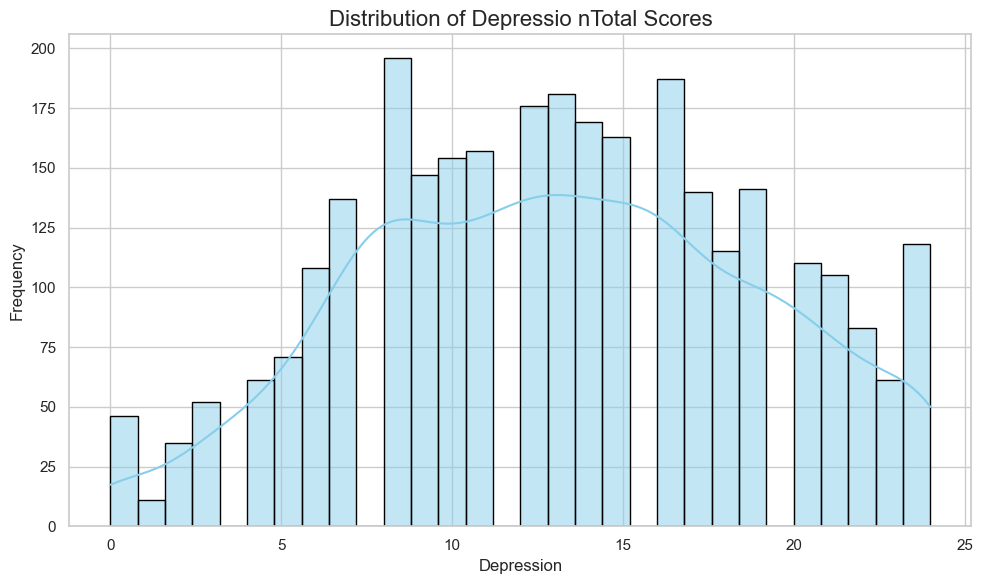

Plot saved successfully to: C:\Users\kau75421\OneDrive - Viavi Solutions Inc\Desktop\ML AI Reference Document\healthyfy\mobilepllc\reports\figures\\depression_distribution.png


In [99]:
try:
    
    # Example: make sure df exists and has the column
    # df = pd.read_csv('your_file.csv')
    # Simulated sample data if needed
    # df = pd.DataFrame({'phq8_total': np.random.normal(loc=10, scale=5, size=1000)})

    # Set Seaborn style
    sns.set(style="whitegrid")

    # Create output folder if it doesn't exist
    #output_folder = 'plots'
    #os.makedirs(output_folder, exist_ok=True)

    # Create the distribution plot
    plt.figure(figsize=(10, 6))
    sns.histplot(df['Depression'], kde=True, bins=30, color='skyblue', edgecolor='black')

    # Add titles and labels
    plt.title('Distribution of Depressio nTotal Scores', fontsize=16)
    plt.xlabel('Depression', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)

    # Save the plot
    plt.tight_layout()
    save_path = os.path.join(output_folder, 'depression_distribution.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"Plot saved successfully to: {save_path}")

except Exception as e:
    print("An error occurred:", str(e))

In [100]:
skewness = df['Depression'].skew()
print(f"Skewness: {skewness:.2f}")
print(f"Hence data is not skewed")

Skewness: -0.04
Hence data is not skewed


In [101]:
# Effect of age on depression 
try:
    # 1. Create age buckets
    age_bins = [0, 20, 30, 40, 50, 60, 70, 100]
    age_labels = ['<20', '20-29', '30-39', '40-49', '50-59', '60-69', '70+']
    df['age_bucket'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels, right=False)

    # 2. Group by age bucket and compute average PHQ-8 score
    age_phq8_grouped = df.groupby('age_bucket')['Depression'].agg(['mean', 'count']).reset_index()

    # 3. Plot the results
    plt.figure(figsize=(10, 6))
    sns.barplot(data=age_phq8_grouped, x='age_bucket', y='mean', palette='viridis',legend=False)
    plt.title('Average Depression Total Score by Age Group')
    plt.xlabel('Age Group')
    plt.ylabel('Mean Depression Score')
    plt.grid(axis='y')
    plt.tight_layout()

    # 4. Save the plot
    output_path = os.path.join(output_folder, 'age_distribution.png')
    plt.savefig(output_path)
    plt.close()

    print(f"Plot saved successfully at: {output_path}")

except Exception as e:
    print(f"An error occurred: {e}")

Plot saved successfully at: C:\Users\kau75421\OneDrive - Viavi Solutions Inc\Desktop\ML AI Reference Document\healthyfy\mobilepllc\reports\figures\\age_distribution.png


C:\Users\kau75421\AppData\Local\Temp\ipykernel_28796\1916682236.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_phq8_grouped = df.groupby('age_bucket')['Depression'].agg(['mean', 'count']).reset_index()
C:\Users\kau75421\AppData\Local\Temp\ipykernel_28796\1916682236.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=age_phq8_grouped, x='age_bucket', y='mean', palette='viridis',legend=False)


* *Higher scores in younger age groups (<30): This is common in many studies due to academic/career stress, uncertainty, and social pressures.*

* *Lower or more stable scores in midlife (30–60): This age group may experience fewer fluctuations once life stabilizes.*

* *An uptick in older age (70+): If visible, this may be due to health decline, isolation, or retirement-related factors.*

In [102]:
df.columns

Index(['Worthlessness', 'Interest', 'Psychomotor', 'Age', 'Sleep', 'Energy',
       'Mood', 'Activity', 'Suicidality', 'Screener', 'Concentration',
       'Appetite', 'Severity', 'Depression', 'age_bucket'],
      dtype='object')

In [103]:

# 1. Define feature list
features = [
    'Worthlessness', 'Interest', 'Psychomotor', 'Age', 'Sleep', 'Energy',
    'Mood', 'Activity', 'Suicidality', 'Screener', 'Concentration',
    'Appetite', 'Severity', 'Depression'
]

# 2. Compute correlation matrix and extract correlation with 'Depression'
corr_matrix = df[features].corr()
target_corr = corr_matrix['Depression'].drop('Depression').sort_values(ascending=False)


# 4. Plot and save the correlation barplot
plt.figure(figsize=(10, 6))
sns.barplot(x=target_corr.values, y=target_corr.index, palette='coolwarm')
plt.title('Correlation of Features with Depression')
plt.xlabel('Correlation Coefficient')
plt.grid(axis='x')
plt.tight_layout()

# 5. Save the figure
output_path = os.path.join(output_folder, 'correlation_feature.png')
plt.savefig(output_path)
plt.close()

print(f"Correlation plot saved successfully at: {output_path}")


Correlation plot saved successfully at: C:\Users\kau75421\OneDrive - Viavi Solutions Inc\Desktop\ML AI Reference Document\healthyfy\mobilepllc\reports\figures\\correlation_feature.png


C:\Users\kau75421\AppData\Local\Temp\ipykernel_28796\2727274713.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_corr.values, y=target_corr.index, palette='coolwarm')


*Top Correlated Features*  
*Severity (~0.95 correlation): This is the most strongly related to depression, which makes sense because it likely reflects overall symptom intensity.*  

*Screener (~0.85): Very strong relationship — people flagged in the initial screener tend to have higher depression scores.*  

*Mood, Interest, Concentration, Worthlessness (~0.7–0.8): These emotional and cognitive features are highly linked with depression scores.*  

*Moderately Correlated Features*  
*Energy, Appetite, Sleep (~0.6): Physical symptoms also show a noticeable relationship with depression, though slightly less than mood-based features.*  

*Psychomotor (~0.5): This feature (related to body movement or slowness) is moderately correlated.*  

* Low or Weak Correlation*  
*Suicidality (~0.4): This is a serious symptom, but it doesn’t correlate as strongly as others — could be due to less frequent reporting.*  

*Activity (~0.1) and Age (~0.05): These have almost no linear correlation with depression. Age especially seems to have little direct relationship here.*

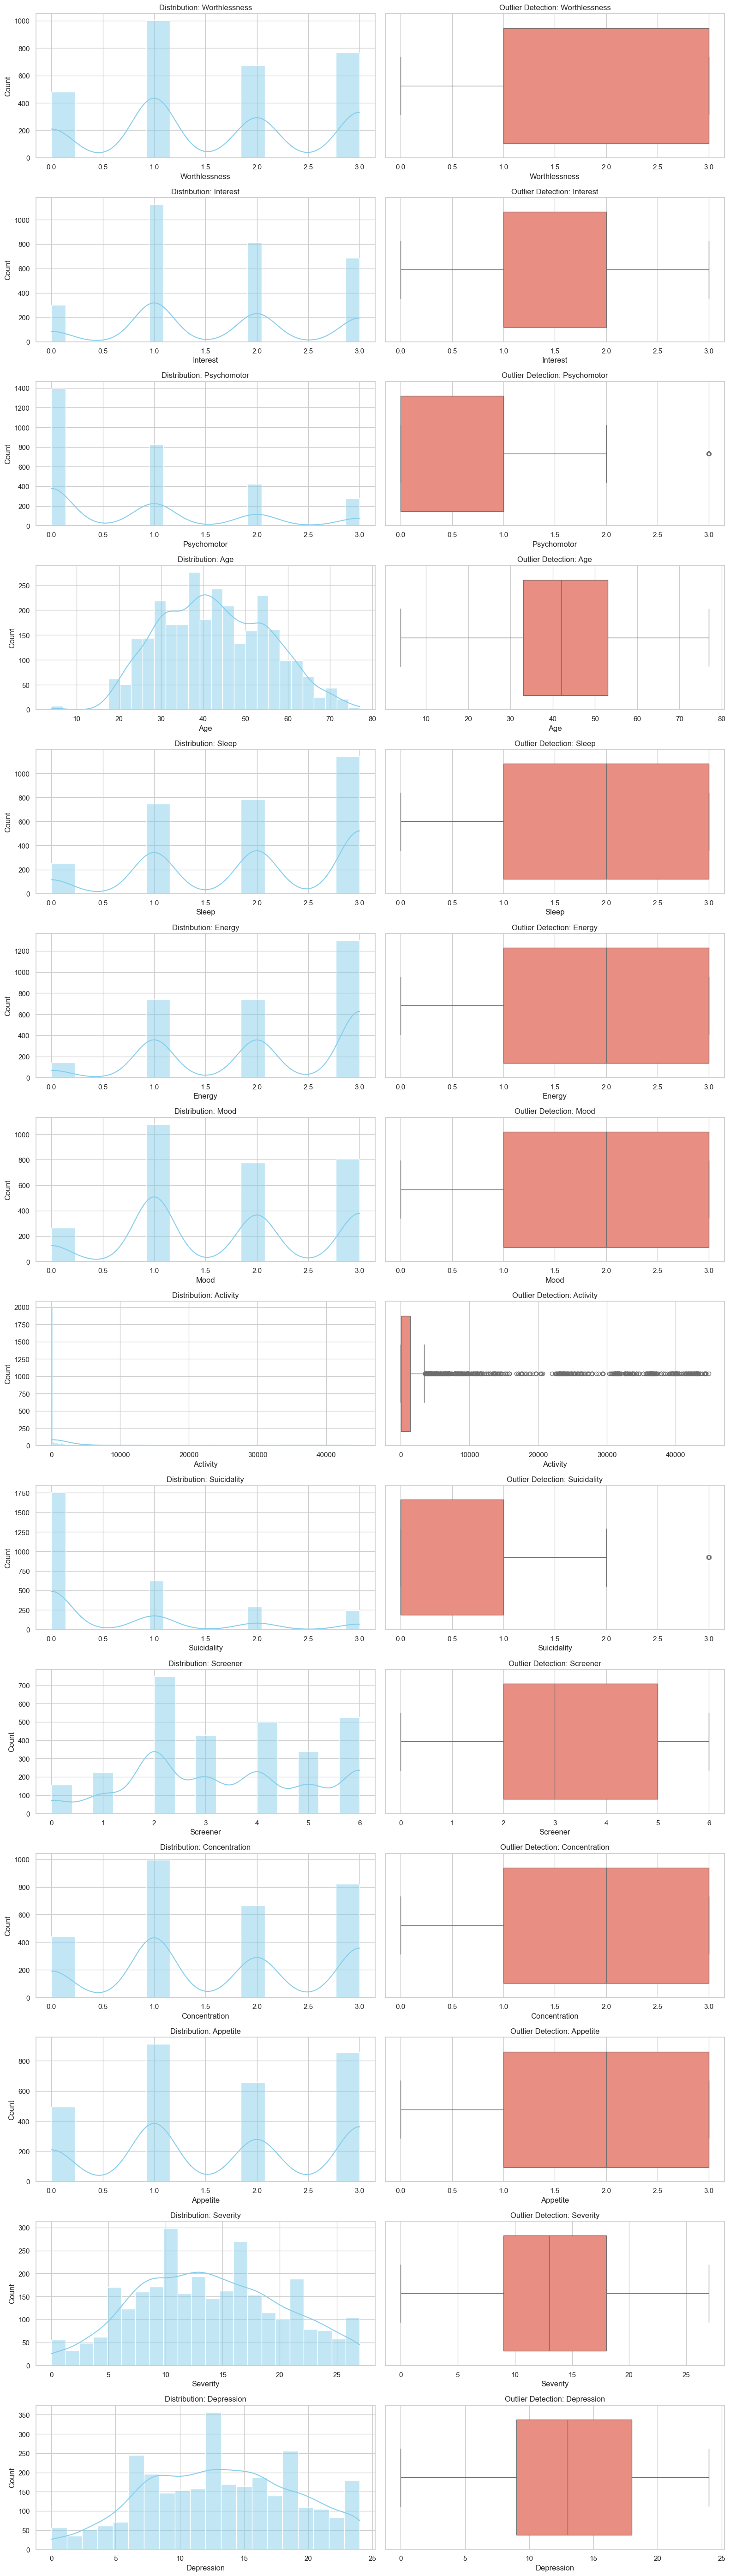


Outlier summary using Z-score method (|z| > 3):
Worthlessness: 0 outliers
Interest: 0 outliers
Psychomotor: 0 outliers
Age: 7 outliers
Sleep: 0 outliers
Energy: 0 outliers
Mood: 0 outliers
Activity: 136 outliers
Suicidality: 0 outliers
Screener: 0 outliers
Concentration: 0 outliers
Appetite: 0 outliers
Severity: 0 outliers
Depression: 0 outliers


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
import os

# Sample placeholder: Replace with your actual DataFrame
# df = pd.read_csv('your_data.csv')

features = [
    'Worthlessness', 'Interest', 'Psychomotor', 'Age', 'Sleep', 'Energy',
    'Mood', 'Activity', 'Suicidality', 'Screener', 'Concentration',
    'Appetite', 'Severity', 'Depression'
]

# Create output folder if not exists
output_folder = 'output_folder'
os.makedirs(output_folder, exist_ok=True)
output_path = os.path.join(output_folder, 'distribution-outlier.png')

# Set up visual style
sns.set(style="whitegrid")
rows = len(features)
plt.figure(figsize=(16, rows * 4))

# Plotting
for i, feature in enumerate(features):
    # Histogram
    plt.subplot(rows, 2, 2*i + 1)
    sns.histplot(df[feature], kde=True, color='skyblue')
    plt.title(f'Distribution: {feature}')

    # Boxplot
    plt.subplot(rows, 2, 2*i + 2)
    sns.boxplot(x=df[feature], color='salmon')
    plt.title(f'Outlier Detection: {feature}')
    plt.tight_layout()
    plt.savefig(output_path)
    plt.show()



# Z-score method for outlier detection
print("\nOutlier summary using Z-score method (|z| > 3):")
for feature in features:
    if pd.api.types.is_numeric_dtype(df[feature]):
        z_scores = zscore(df[feature].dropna())
        outliers = (abs(z_scores) > 3).sum()
        print(f"{feature}: {outliers} outliers")


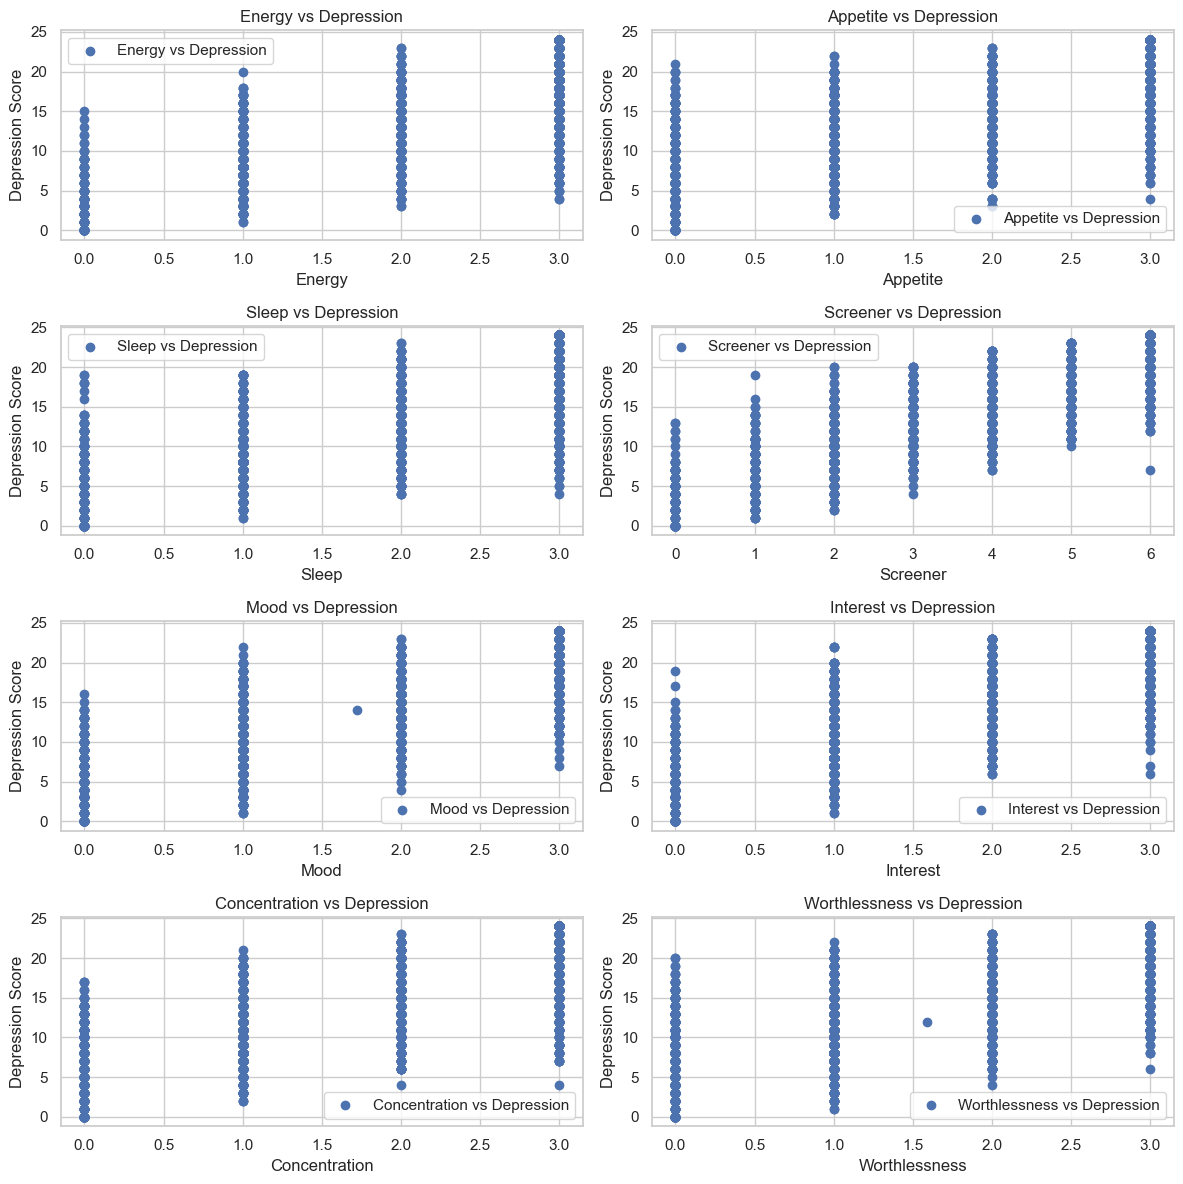

In [105]:
features = ['Energy', 'Appetite', 'Sleep', 'Screener', 'Mood', 'Interest', 'Concentration', 'Worthlessness']

# Create the plots
fig, axes = plt.subplots(4, 2, figsize=(12, 12))  # Create a 4x2 grid of subplots

# Flatten axes for easier iteration
axes = axes.flatten()

# Loop through the features and plot each one as a scatter plot
for i, feature in enumerate(features):
    axes[i].scatter(df[feature], df['Depression'], label=f'{feature} vs Depression', color='b')
    axes[i].set_title(f'{feature} vs Depression')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Depression Score')
    axes[i].grid(True)
    axes[i].legend()

# Adjust layout for better spacing
plt.tight_layout()
# 5. Save the figure
output_path = os.path.join(output_folder, 'scatter _plot.png')
plt.savefig(output_path)
# Show the plot
plt.show()

 "*Energy: Moderate spread in depression scores—some relationship present.*",
    "*Appetite: Moderate variance—suggests a weak to moderate link with depression.*",
    "*Sleep: High variance—poor predictor of depression.*",
    "*Screener: Low variance—very strong and consistent predictor of depression.*",
    "*Mood: Low variance—strong negative relationship with depression.*",
    "*Interest: Low variance—strong predictor; higher interest means lower depression.*",
    "*Concentration: Moderate to high variance—relationship is less clear.*",
    "*Worthlessness: Low variance—very strong and consistent predictor of high depression.*"